# Cost of Living File Cleaning
---

## Table of Contents
1. [Load Data](#1-load-data)
2. [Select Columns](#2-select-columns)
3. [Rename & Transform Columns](#3-rename--transform-columns)
4. [Standardise & Deduplicate](#4-standardise--deduplicate)
5. [Data Validation](#5-data-validation)
6. [Range Validation](#6-range-validation)
7. [Fill Missing Values](#7-fill-missing-values)
8. [Final Dataset Preview and Checks](#8-final-dataset-preview-and-checks)

## 1. Load Data
The raw dataset is loaded from CSV and the first 10 rows are displayed to get a feel for the data and its types.

In [36]:
# Importing the cost of living CSV file and display the first 10 rows of the dataset.
import pandas as pd
cost_of_living = pd.read_csv('cost-of-living.csv')
cost_of_living.head(10)


,Unnamed: 0,city,country,x1,x2,x3,x4,x5,x6,x7,...,x47,x48,x49,x50,x51,x52,x53,x54,x55,data_quality
0,0,Delhi,India,4.90,22.04,4.28,1.84,3.67,1.78,0.48,...,36.26,223.87,133.38,596.16,325.82,2619.46,1068.90,586.35,7.96,1
1,1,Shanghai,China,5.59,40.51,5.59,1.12,4.19,3.96,0.52,...,121.19,1080.07,564.30,2972.57,1532.23,17333.09,9174.88,1382.83,5.01,1
2,2,Jakarta,Indonesia,2.54,22.25,3.50,2.02,3.18,2.19,0.59,...,80.32,482.85,270.15,1117.69,584.37,2694.05,1269.44,483.19,9.15,1
3,3,Manila,Philippines,3.54,27.40,3.54,1.24,1.90,2.91,0.93,...,61.82,559.52,281.78,1754.40,684.81,3536.04,2596.44,419.02,7.80,1
4,4,Seoul,South Korea,7.16,52.77,6.03,3.02,4.52,3.86,1.46,...,108.30,809.83,583.60,2621.05,1683.74,21847.94,10832.90,2672.23,3.47,1
5,5,Bangkok,Thailand,2.60,28.09,5.62,2.25,4.21,2.06,0.50,...,93.22,584.77,280.92,1994.97,915.48,5229.36,2504.73,615.33,5.64,1
6,6,Kolkata,India,2.00,14.69,3.67,2.20,3.67,1.60,0.36,...,32.30,148.95,84.21,397.89,247.53,1057.12,583.39,536.14,8.28,1
7,7,Guangzhou,China,4.05,27.94,4.89,0.84,1.68,3.41,0.44,...,46.25,523.26,311.48,1218.89,675.11,12650.42,5325.41,1189.07,5.11,1
8,8,Mumbai,India,3.67,18.36,3.67,2.45,4.28,2.49,0.46,...,41.04,514.39,285.88,1388.63,681.14,6073.04,2768.67,627.64,7.87,1
9,9,Beijing,China,4.19,30.73,5.59,1.40,4.05,4.55,0.51,...,117.38,1176.59,660.60,2732.46,1426.41,17450.87,9463.20,1514.55,5.00,1


## 2. Select Columns
Only the columns relevant to a holiday destination cost comparison are kept: country, meal cost, transport, and accommodation.

In [37]:
# Keeping only the columns that I want to use for the analysis.
cost_of_living_cols = ['country','x2', 'x28', 'x48']
cost_of_living_clean = cost_of_living
cost_of_living_clean = cost_of_living_clean[cost_of_living_cols].copy()
cost_of_living_clean.head(10)


,country,x2,x28,x48
0,India,22.04,0.49,223.87
1,China,40.51,0.56,1080.07
2,Indonesia,22.25,0.22,482.85
3,Philippines,27.40,0.53,559.52
4,South Korea,52.77,0.98,809.83
5,Thailand,28.09,1.24,584.77
6,India,14.69,0.21,148.95
7,China,27.94,0.35,523.26
8,India,18.36,0.24,514.39
9,China,30.73,0.70,1176.59


## 3. Rename & Transform Columns
Column names are renamed from shorthand codes to descriptive labels. The meal cost for 2 is halved to give a per-person figure.

In [38]:
# Renaming columns to descriptive names.
cost_of_living_clean = cost_of_living_clean.rename(columns={
    'x2': 'Mid_range_meal_for_2',
    'x28': 'One_way_local_transport_ticket',
    'x48': 'Apartment'
})
cost_of_living_clean.head(10)


,country,Mid_range_meal_for_2,One_way_local_transport_ticket,Apartment
0,India,22.04,0.49,223.87
1,China,40.51,0.56,1080.07
2,Indonesia,22.25,0.22,482.85
3,Philippines,27.40,0.53,559.52
4,South Korea,52.77,0.98,809.83
5,Thailand,28.09,1.24,584.77
6,India,14.69,0.21,148.95
7,China,27.94,0.35,523.26
8,India,18.36,0.24,514.39
9,China,30.73,0.70,1176.59


In [39]:
# Dividing Mid_range_meal_for_2 by 2 to get cost per person, then renaming the column.
cost_of_living_clean['Mid_range_meal_for_2'] = (cost_of_living_clean['Mid_range_meal_for_2'] / 2).round(2)
cost_of_living_clean = cost_of_living_clean.rename(columns={'Mid_range_meal_for_2': 'Mid_range_meal_pp'})
cost_of_living_clean.head(10)


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment
0,India,11.02,0.49,223.87
1,China,20.26,0.56,1080.07
2,Indonesia,11.12,0.22,482.85
3,Philippines,13.70,0.53,559.52
4,South Korea,26.38,0.98,809.83
5,Thailand,14.04,1.24,584.77
6,India,7.34,0.21,148.95
7,China,13.97,0.35,523.26
8,India,9.18,0.24,514.39
9,China,15.36,0.70,1176.59


## 4. Standardise & Deduplicate
Country names are title-cased for consistency, then duplicate countries are resolved by averaging their numeric values so no data is lost.

In [40]:
# Quick standardization step to ensure consistent capitalization before checking for duplicates.
cost_of_living_clean['country'] = cost_of_living_clean['country'].str.title()

# For any duplicate countries, average the numeric columns so no data is lost.
before = len(cost_of_living_clean)
cost_of_living_clean = cost_of_living_clean.groupby('country', as_index=False).mean(numeric_only=True).round(2)
after = len(cost_of_living_clean)

print(f"Rows before: {before}")
print(f"Rows after:  {after}")
print(f"Duplicates resolved: {before - after}")
cost_of_living_clean.head(10)


Rows before: 4874
Rows after:  204
Duplicates resolved: 4670


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment
0,Afghanistan,3.39,0.22,80.96
1,Albania,12.48,0.46,197.04
2,Algeria,6.74,0.21,144.80
3,American Samoa,3.28,NaN,88.18
4,Andorra,20.17,1.90,811.73
5,Angola,32.12,0.59,220.39
6,Anguilla,85.00,NaN,800.00
7,Antigua And Barbuda,46.26,1.02,NaN
8,Argentina,13.91,0.37,211.91
9,Armenia,15.84,0.25,580.29


## 5. Data Validation
Check that each column holds the expected data type, scan for missing or blank values, and flag any  negative prices.

In [41]:
# Confirm that each column holds the type of data I actually expect
# country should be strings, cost columns should be numeric
print("Data Type Validation:")
print("-" * 40)

valid = cost_of_living_clean['country'].apply(lambda x: isinstance(x, str)).all()
print(f"country: all strings = {valid}")

for col in ['Mid_range_meal_pp', 'One_way_local_transport_ticket', 'Apartment']:
    valid = cost_of_living_clean[col].apply(lambda x: isinstance(x, (int, float))).all()
    print(f"{col}: all numeric = {valid}")

print("-" * 40)


Data Type Validation:
----------------------------------------
country: all strings = True
Mid_range_meal_pp: all numeric = True
One_way_local_transport_ticket: all numeric = True
Apartment: all numeric = True
----------------------------------------


In [42]:
# Check every column for missing or blank values
print("Missing value counts per column:")
print("-" * 40)
print(f"country:                            {cost_of_living_clean['country'].isna().sum()} NaN  |  {(cost_of_living_clean['country'] == '').sum()} blank")
print(f"Mid_range_meal_pp:                  {cost_of_living_clean['Mid_range_meal_pp'].isna().sum()} NaN  |  {(cost_of_living_clean['Mid_range_meal_pp'] == '').sum()} blank")
print(f"One_way_local_transport_ticket:     {cost_of_living_clean['One_way_local_transport_ticket'].isna().sum()} NaN  |  {(cost_of_living_clean['One_way_local_transport_ticket'] == '').sum()} blank")
print(f"Apartment:                          {cost_of_living_clean['Apartment'].isna().sum()} NaN  |  {(cost_of_living_clean['Apartment'] == '').sum()} blank")

# Display all rows that contain at least one NaN value.
cost_of_living_clean[cost_of_living_clean.isna().any(axis=1)]

Missing value counts per column:
----------------------------------------
country:                            0 NaN  |  0 blank
Mid_range_meal_pp:                  2 NaN  |  0 blank
One_way_local_transport_ticket:     11 NaN  |  0 blank
Apartment:                          4 NaN  |  0 blank


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment
3,American Samoa,3.28,NaN,88.18
6,Anguilla,85.00,NaN,800.00
7,Antigua And Barbuda,46.26,1.02,NaN
35,Chad,15.84,NaN,1103.64
39,Comoros,NaN,NaN,NaN
40,Cook Islands,24.86,NaN,161.54
72,Guinea-Bissau,7.51,NaN,341.22
124,Nauru,16.76,NaN,1676.56
132,North Korea,10.24,0.65,NaN
154,Sao Tome And Principe,20.78,NaN,207.74


In [43]:
# Prices should never be negative — a negative cost makes no real-world sense.
print("Negative value check:")
print("-" * 40)
for col in ['Mid_range_meal_pp', 'One_way_local_transport_ticket', 'Apartment']:
    neg_count = (cost_of_living_clean[col] < 0).sum()
    print(f"{col}: {neg_count} negative values")
print("-" * 40)


Negative value check:
----------------------------------------
Mid_range_meal_pp: 0 negative values
One_way_local_transport_ticket: 0 negative values
Apartment: 0 negative values
----------------------------------------


## 6. Range Validation
Display the min and max of each numeric column to check if it falls within realistic bounds, and visualize the spread with box plots.

In [44]:
numeric_cols = [ 'Mid_range_meal_pp', 'One_way_local_transport_ticket', 'Apartment']

min_max = cost_of_living_clean[numeric_cols].agg(['min', 'max'])
print(min_max.to_string())

     Mid_range_meal_pp  One_way_local_transport_ticket  Apartment
min               3.28                            0.00      72.76
max              85.00                            6.07    5411.90


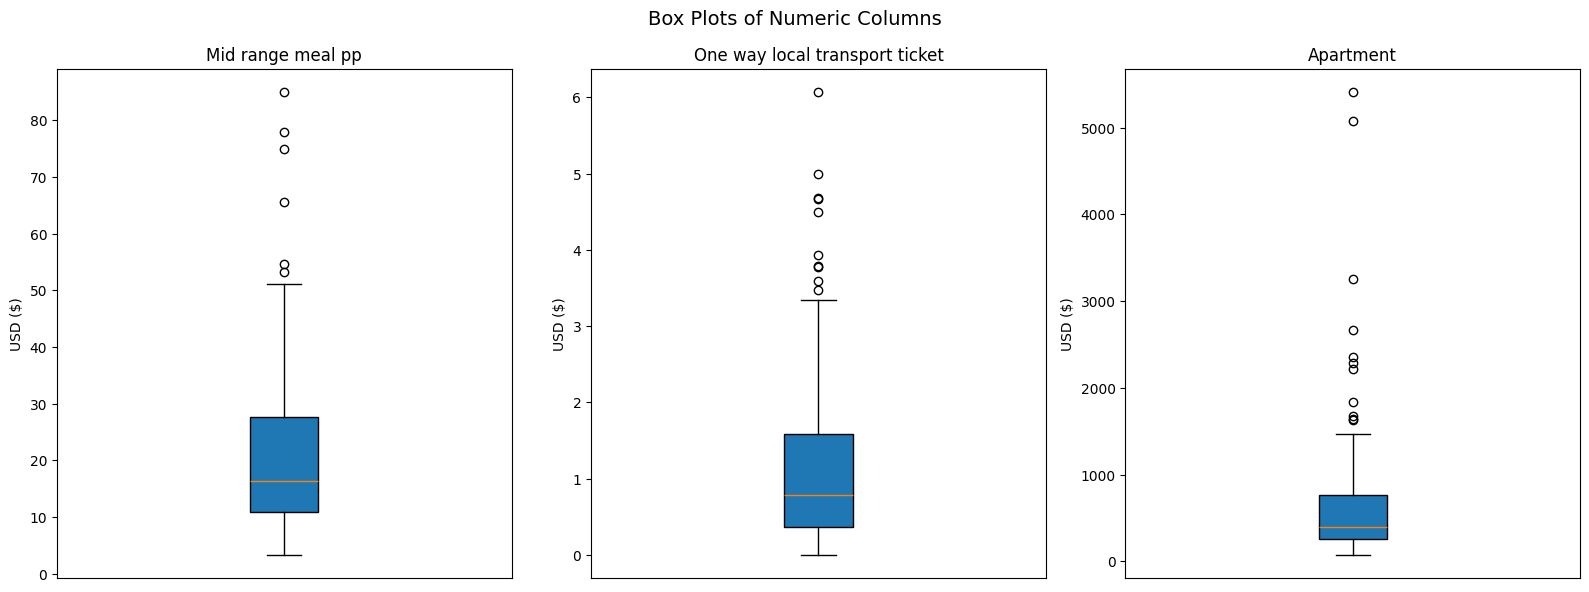

In [45]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Box Plots of Numeric Columns', fontsize=14)

for ax, col in zip(axes, numeric_cols):
    ax.boxplot(cost_of_living_clean[col].dropna(), patch_artist=True)
    ax.set_title(col.replace('_', ' '))
    ax.set_ylabel('USD ($)')
    ax.set_xticks([])

plt.tight_layout()
plt.show()


## 7. Fill Missing Values
Missing values are imputed using the most appropriate statistic for each column.

In [46]:
# --- Filling Missing Values ---


# I will use MEDIAN to fill Mid-range meal per person  
# A handful of luxury destinations could end up
# driving the mean way up, making meals look more expensive than they really are
# for the typical traveller. The median cuts through that noise and gives the
# price you'd actually expect to pay in most cities.
meal_median = cost_of_living_clean['Mid_range_meal_pp'].median()
cost_of_living_clean['Mid_range_meal_pp'] = cost_of_living_clean['Mid_range_meal_pp'].fillna(meal_median)

# For One-way transport ticket I will use MODE to fill the missing values.
# Public transport fares are often fixed or government-subsidised, so in
# practice a lot of cities share the exact same price point 
transport_mode = cost_of_living_clean['One_way_local_transport_ticket'].mode()[0]
cost_of_living_clean['One_way_local_transport_ticket'] = cost_of_living_clean['One_way_local_transport_ticket'].fillna(transport_mode)

# Apartment / accommodation → fill with MEDIAN
# This column has the widest range from 72.76 vs 5411.90. 
# The mean would be dragged so far by those extremes that it
# would make the typical price look much higher than it really is.

apt_median = cost_of_living_clean['Apartment'].median()
cost_of_living_clean['Apartment'] = cost_of_living_clean['Apartment'].fillna(apt_median)

print("Missing values after imputation:")
print(cost_of_living_clean.isna().sum())
cost_of_living_clean.head(10)


Missing values after imputation:
country                           0
Mid_range_meal_pp                 0
One_way_local_transport_ticket    0
Apartment                         0
dtype: int64


,country,Mid_range_meal_pp,One_way_local_transport_ticket,Apartment
0,Afghanistan,3.39,0.22,80.96
1,Albania,12.48,0.46,197.04
2,Algeria,6.74,0.21,144.80
3,American Samoa,3.28,0.19,88.18
4,Andorra,20.17,1.90,811.73
5,Angola,32.12,0.59,220.39
6,Anguilla,85.00,0.19,800.00
7,Antigua And Barbuda,46.26,1.02,395.29
8,Argentina,13.91,0.37,211.91
9,Armenia,15.84,0.25,580.29


## 8. Final Dataset Preview and Checks
Statistical summary and a final info check to confirm the dataset is fully clean and ready for analysis.

In [47]:
# Statistical summary of the fully cleaned dataset.
print("Statistical Summary:")
print(cost_of_living_clean[numeric_cols].describe().round(2).to_string())


Statistical Summary:
       Mid_range_meal_pp  One_way_local_transport_ticket  Apartment
count             204.00                          204.00     204.00
mean               20.69                            1.11     618.92
std                13.72                            1.06     669.95
min                 3.28                            0.00      72.76
25%                10.98                            0.34     259.62
50%                16.34                            0.74     395.29
75%                27.52                            1.55     765.89
max                85.00                            6.07    5411.90


In [48]:
# Final confirmation that the dataset is fully clean and ready for analysis.
print("Final Dataset Info:")
print("-" * 40)
cost_of_living_clean.info()


Final Dataset Info:
----------------------------------------
<class 'pandas.DataFrame'>
RangeIndex: 204 entries, 0 to 203
Data columns (total 4 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   country                         204 non-null    str    
 1   Mid_range_meal_pp               204 non-null    float64
 2   One_way_local_transport_ticket  204 non-null    float64
 3   Apartment                       204 non-null    float64
dtypes: float64(3), str(1)
memory usage: 6.5 KB
